In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import sys

In [2]:
# Load the H5AD file
adata_original = sc.read_h5ad('ovary_Puck_230517_39.h5ad')

adata = adata_original

def isolate_gene_values (gene_name):
    gene_values = pd.DataFrame(adata[:, gene_name].X.toarray(), columns = [gene_name], index = adata.obs_names)
    return gene_values

coordinates = pd.DataFrame(adata.obsm["spatial"], columns = ['x','y'], index = adata.obs_names)

In [3]:
df = pd.concat([coordinates, isolate_gene_values("Serpine2"),isolate_gene_values("Tagln")], axis =1)

df = df.sample(frac=1)
df = df.head(1000)

df['x'] = df['x'] /df['x'].median()
df['y'] = df['y'] /df['y'].median()
df['Serpine2'] = df['Serpine2'] / 1000
df['Tagln'] = df['Tagln'] / 1000

df

# print(len(isolate_gene_values("Tagln")["Tagln"].unique()))
# print(len(isolate_gene_values("Serpine2")["Serpine2"].unique()))

,x,y,Serpine2,Tagln
GCANCTAACGTTGT-1-2,0.564131,0.896896,0.208189,0.000000
GCATGGCCGCAAGC-1-2,0.720589,0.748046,0.160171,0.000000
ACTATTATAGNTCT-1-2,0.840937,1.140922,0.241255,0.000000
TTACATCACGAGGA-1-2,1.277718,1.263865,0.000000,0.444444
NAAGATACTGCGGA-1-2,1.156674,1.197796,0.000000,0.000000
...,...,...,...,...
CTTATTAACATGTT-1-2,1.233841,0.942976,0.529100,0.000000
CTCCTGCGGAGGTA-1-2,1.120231,0.625363,0.000000,0.000000
AGCGGTTATAGAGT-1-2,0.777145,0.793308,0.215054,0.215054
CAAGTGTGAGGACT-1-2,1.205198,1.284895,0.000000,1.123595


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import multivariate_normal
from sklearn.gaussian_process.kernels import Matern
from scipy.interpolate import griddata
from scipy.linalg import cho_solve, cho_factor
from scipy.optimize import minimize

# Define the Matern covariance function
def matern_covariance(X, length_scale=1.0, nu=1.5, sigma2=1.0):
    pairwise_dists = squareform(pdist(X, 'euclidean'))
    kernel = Matern(length_scale=length_scale, nu=nu)
    return sigma2 * kernel(pairwise_dists)

# Generate bivariate Matern covariance matrix with distinct parameters
def generate_bivariate_matern_covariance(X, params, nugget = 1e-1, sigma1=1, sigma2=2):
    nu1, a1, sigma1, nu2, a2, sigma2, nu12, a12, rho = params
    K1 = matern_covariance(X, length_scale=a1, nu=nu1, sigma2=sigma1)
    K2 = matern_covariance(X, length_scale=a2, nu=nu2, sigma2=sigma2)
    K12 = rho * matern_covariance(X, length_scale=a12, nu=nu12, sigma2=np.sqrt(sigma1 * sigma2))
    K = np.block([[K1, K12], [K12.T, K2]])
    # Adding nugget effect to the diagonal blocks
    K += np.eye(K.shape[0]) * nugget
    return K

# Check if matrix is positive definite
def is_positive_definite(K):
    try:
        np.linalg.cholesky(K)
        return True
    except np.linalg.LinAlgError:
        return False

# def list_to_dict(params):
#     return {
#         'nu1': params[0], 'a1': params[1], 'sigma1': params[2],
#         'nu2': params[3], 'a2': params[4], 'sigma2': params[5],
#         'nu12': params[6], 'a12': params[7], 'rho': params[8]
#     }
    
def constraint_function(params):
    K = generate_bivariate_matern_covariance(X,params)
    if is_positive_definite(K)==True:
        return 0
    if is_positive_definite(K)==False:
        return -1
    return -2


# Negative log-likelihood function for optimization
def negative_log_likelihood(params, X, y):
    K = generate_bivariate_matern_covariance(X, params)
    if not is_positive_definite(K):
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf
    
    try:
        L = cho_factor(K)
        alpha = cho_solve(L, y)
        log_likelihood = -0.5 * np.dot(y.T, alpha)
        log_likelihood -= np.sum(np.log(np.diag(L[0])))
        log_likelihood -= K.shape[0] / 2 * np.log(2 * np.pi)
        return -log_likelihood
    except np.linalg.LinAlgError:
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf
        
# Plotting function for data and continuous fields
def plot_data_and_fields(X, data):
    # Plotting the data
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(X[:, 0], X[:, 1], c=data[:, 0], cmap='viridis', edgecolor='k')
    plt.colorbar(label='Variable 1 Values')
    plt.title('Spatial Distribution for Variable 1')
    plt.xlabel('Coordinate 1')
    plt.ylabel('Coordinate 2')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(X[:, 0], X[:, 1], c=data[:, 1], cmap='viridis', edgecolor='k')
    plt.colorbar(label='Variable 2 Values')
    plt.title('Spatial Distribution for Variable 2')
    plt.xlabel('Coordinate 1')
    plt.ylabel('Coordinate 2')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [5]:
# Simulate bivariate data

X = np.random.uniform(-3., 3., (2000, 2))
# Generate covariance matrix
mean = np.zeros(2 * len(X))
initial_params = [1.5, 1, 1, 0.5, 0.2,1,  1, 0.6, 0.5]
K = generate_bivariate_matern_covariance(X, initial_params)

# # Check if matrix is positive definite
# print("Is the covariance matrix positive definite?", is_positive_definite(K))

data = multivariate_normal.rvs(mean=mean, cov=K).reshape(-1, 2)
print("working with simulated data set")

# Generate and Flatten the data for optimization
y_data = data.reshape(-1)

working with simulated data set


In [6]:
# Real data
X = df[['x','y']].to_numpy()
data = df[['Tagln','Serpine2']].to_numpy()
print("working with real data set")

# Generate and Flatten the data for optimization
y_data = data.reshape(-1)

working with real data set


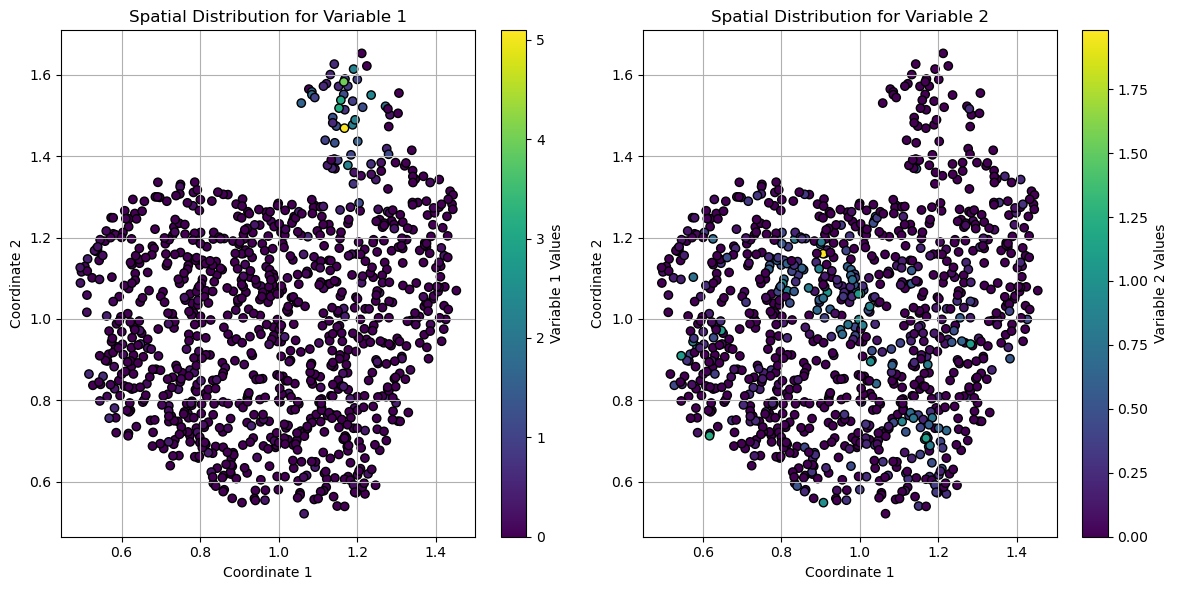

In [7]:
# Plot the data and continuous fields
plot_data_and_fields(X, data)

In [8]:
%time
# Bounds and options for the optimizer
# Bounds for each parameter
bounds = [
    (0.1, 5.0),  # nu1: smoothness parameter for the first variable
    (0.1, 1.5),  # a1: length scale for the first variable
    (1, 1),      # sigma1: standard deviation for the first variable (fixed)
    (0.1, 5.0),  # nu2: smoothness parameter for the second variable
    (0.1, 1.5),  # a2: length scale for the second variable
    (1, 1),      # sigma2: standard deviation for the second variable (fixed)
    (0.1, 5.0),  # nu12: smoothness parameter for the cross-covariance
    (0.1, 1.5),  # a12: length scale for the cross-covariance
    (-5.0, 5.0)   # rho: correlation coefficient
]
constraints = [{'type': 'eq', 'fun': constraint_function}]
# options = {'maxiter': 10000, 'ftol': 1e-16, 'gtol': 1e-15, 'eps': 1e-9}
# options = {'maxiter': 10000, 'ftol': 1e-16}
options = {'maxiter': 1000000, 'gtol': 1e-15}
initial_params = [1.5, 1, 1, 0.5, 0.2,1,  1, 0.6, 0.5]
# Minimize the negative log-likelihood
result = minimize(negative_log_likelihood, initial_params, args=(X, y_data), bounds=bounds, constraints = constraints, options=options, method = "trust-constr")
# Output the optimal parameters with descriptions
param_labels = [
    "nu1 (smoothness for variable 1)",
    "a1 (length scale for variable 1)",
    "sigma1 (variance for variable 1)",
    "nu2 (smoothness for variable 2)",
    "a2 (length scale for variable 2)",
    "sigma2 (variance for variable 2)",
    "nu12 (smoothness for cross-covariance)",
    "a12 (length scale for cross-covariance)",
    "rho (correlation coefficient)"
]
print("Optimal parameters:")
for label, value in zip(param_labels, result.x):
    print(f"{label}: {value:.2f}")
print("Success:", result.success)
print("Message:", result.message)
print("Number of iterations:", result.nit)

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 5.96 μs


/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/scipy/optimize/_trustregion_constr/projections.py:181: UserWarning: Singular Jacobian matrix. Using SVD decomposition to perform the factorizations.
  warn('Singular Jacobian matrix. Using SVD decomposition to ' +
/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/home/zc362/.conda/envs/myenv/lib/python3.12/site-packages/scipy/optimize/_hessian_update_strategy.py:182: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  warn('delta_grad == 0.0. Check if the approximated '


Optimal parameters:
nu1 (smoothness for variable 1): 1.50
a1 (length scale for variable 1): 1.00
sigma1 (variance for variable 1): 1.00
nu2 (smoothness for variable 2): 0.50
a2 (length scale for variable 2): 0.20
sigma2 (variance for variable 2): 1.00
nu12 (smoothness for cross-covariance): 1.00
a12 (length scale for cross-covariance): 0.60
rho (correlation coefficient): 0.50
Success: False
Message: The maximum number of function evaluations is exceeded.
Number of iterations: 1000000


In [9]:
for label, value in zip(param_labels, result.x):
    print(f"{label}: {value:.3f}")

nu1 (smoothness for variable 1): 1.500
a1 (length scale for variable 1): 1.000
sigma1 (variance for variable 1): 1.000
nu2 (smoothness for variable 2): 0.500
a2 (length scale for variable 2): 0.200
sigma2 (variance for variable 2): 1.000
nu12 (smoothness for cross-covariance): 1.000
a12 (length scale for cross-covariance): 0.600
rho (correlation coefficient): 0.500


In [10]:
# Evaluation of negative log-likelihood with perturbed parameters
eps = 1e-3
params_perturbed = [
    [1.5, 1.0, 1, 0.5, 0.2,1,  1, 0.6, 0.5],
    [1.5 + eps, 1 - eps,  1, 0.5 - eps, 0.02 + eps,1,  1 + eps, 0.6 - eps, 0.5 + eps],
    [2.0, 0.9,1,  0.6, 0.3,1,  0.9, 0.5, 0.4],
    [1.5, 1.15355078, 1, 0.5, 0.10000144, 1, 1, 0.40047217, 0.53090718],
    result.x
]

for params in params_perturbed:
    # print(len(params))
    print(negative_log_likelihood(params=params, X=X, y=y_data))

1426.4221477726157
inf
1435.5501046917902
inf
1426.4221477726157


In [11]:
for params in params_perturbed:
    # Generate covariance matrix
    K = generate_bivariate_matern_covariance(X, params)
    
    # Check if matrix is positive definite
    print("Is the covariance matrix positive definite?", is_positive_definite(K))

Is the covariance matrix positive definite? True
Is the covariance matrix positive definite? False
Is the covariance matrix positive definite? True
Is the covariance matrix positive definite? False
Is the covariance matrix positive definite? True


In [12]:
len(K)

2000

Note to self: currently, the code works, but the scipy.optimise minimise does not work as expected.  The raeson I think has to do with the bound and the. way to deal with positive definiteness.  If they just arbitrarily give out some perturbations, then obviously they will get just zero gradient.

For our current testing purpose, we fix $X$.  Furthermore, we will write down a much more constrained version of the problem, where  $a_1=a_2=1$, $\nu_1=1.5$, $\nu_2=0.5$, and only $\rho, a_{12}$ are  to be flexible.  Instead of imposing these through the bounds, I bake everything inside the functions.

In [13]:
# Generate bivariate Matern covariance matrix with distinct parameters
def generate_bivariate_matern_covariance_simplified(X, params, nugget = 1e-1, sigma1=1, sigma2=2):
    nu1=1.5
    a1=1 
    sigma1 =1
    nu2=0.5
    a2=1
    sigma2=1
    nu12= (nu1+nu2)/2
    a12, rho = params
    K1 = matern_covariance(X, length_scale=a1, nu=nu1, sigma2=sigma1)
    K2 = matern_covariance(X, length_scale=a2, nu=nu2, sigma2=sigma2)
    K12 = rho * matern_covariance(X, length_scale=a12, nu=nu12, sigma2=np.sqrt(sigma1 * sigma2))
    K = np.block([[K1, K12], [K12.T, K2]])
    # Adding nugget effect to the diagonal blocks
    K += np.eye(K.shape[0]) * nugget
    return K

def constraint_function_simplified(params):
    K = generate_bivariate_matern_covariance_simplified(X,params)
    if is_positive_definite(K)==True:
        return 0
    if is_positive_definite(K)==False:
        return -1
    return -2



# Negative log-likelihood function for optimization
def negative_log_likelihood_simplified(params, X, y):
    K = generate_bivariate_matern_covariance_simplified(X, params)
    if not is_positive_definite(K):
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf
    
    try:
        L = cho_factor(K)
        alpha = cho_solve(L, y)
        log_likelihood = -0.5 * np.dot(y.T, alpha)
        log_likelihood -= np.sum(np.log(np.diag(L[0])))
        log_likelihood -= K.shape[0] / 2 * np.log(2 * np.pi)
        return -log_likelihood
    except np.linalg.LinAlgError:
        # return sys.float_info.max # np.inf can lead to np.nan, so perhaps this is better.
        return np.inf

In [14]:
# Simulate bivariate data

X = np.random.uniform(-3., 3., (4000, 2))
# Generate covariance matrix
mean = np.zeros(2 * len(X))
initial_params_simplified = [0.6, 0.5]
K = generate_bivariate_matern_covariance_simplified(X, initial_params_simplified)

# # Check if matrix is positive definite
# print("Is the covariance matrix positive definite?", is_positive_definite(K))

data = multivariate_normal.rvs(mean=mean, cov=K).reshape(-1, 2)

# Generate and Flatten the data for optimization
y_data = data.reshape(-1)

print("working with simulated data set")

working with simulated data set


In [15]:
# Set random seed for reproducibility
np.random.seed(42)

# Bounds for each parameter
bounds_simplified = [
    (0.1, 5.0),  # a12: free (length scale for cross-covariance)
    (0.1, 5.0)   # rho: free (correlation coefficient)
]

# Generate random parameter set within bounds
def generate_random_params_simplified(bounds_simplified):
    params = []
    for (low, high) in bounds_simplified:
        if low == high:
            params.append(low)
        else:
            params.append(np.random.uniform(low, high))
    return params

# Generate 10 sets of parameters that satisfy the constraint
valid_params_sets_simplified = [[0.6,0.5]]
while len(valid_params_sets_simplified) < 10:
    params = generate_random_params_simplified(bounds_simplified)
    if constraint_function_simplified(params) == 0:
        valid_params_sets_simplified.append(params)

In [16]:
# Print the generated parameter sets
for i, params in enumerate(valid_params_sets_simplified):
    print(f"Params set {i+1}: {params}")

Params set 1: [0.6, 0.5]
Params set 2: [0.864491338167939, 0.864373149647393]
Params set 3: [0.990942339314793, 0.9986820982818257]
Params set 4: [1.5926074689495167, 0.578593358631281]
Params set 5: [1.7214003217779812, 0.4114359164015159]
Params set 6: [1.2211110109089502, 0.47720155816108567]
Params set 7: [1.4957184224495914, 0.2807460420372107]
Params set 8: [3.420065373027184, 0.18128036174649514]
Params set 9: [3.071502392331991, 0.1450655529214853]
Params set 10: [1.4757845759601935, 0.21914823551412382]


In [17]:
bounds = [(0.1, 5.0),
 (0.1, 1.5)]

options = {'maxiter': 10000, 'gtol': 1e-15}

In [18]:
bounds

[(0.1, 5.0), (0.1, 1.5)]

In [19]:
options

{'maxiter': 10000, 'gtol': 1e-15}

In [20]:
negative_log_likelihood_simplified(params=[0.6,0.5], X=X, y=y_data)

10982.67033278905

In [21]:
negative_log_likelihood_simplified(params=[0.43,0.45], X=X, y=y_data)

10990.023753273039

In [ ]:
initial_params = [1, 0.5]

param_labels = [
    "nu1",
    "a1",
    "sigma1",
    "nu2",
    "a2",
    "sigma2",
    "nu12",
    "a12",
    "rho"
]

constraints_simplified = [{'type': 'eq', 'fun': constraint_function_simplified}]
options = {'maxiter': 1000, 'gtol': 1e-15, 'xtol':1e-15}



# Minimize the negative log-likelihood
for i, params in enumerate(valid_params_sets_simplified):
    result = minimize(negative_log_likelihood_simplified, params, args=(X, y_data), bounds=bounds, constraints = constraints_simplified, options=options, method = "trust-constr")
    # Output the optimal parameters with descriptions
    print(result.x)
    print("Success:", result.success)
    print("Message:", result.message)
    print("Number of iterations:", result.nit)

In [ ]:
# Minimize the negative log-likelihood
for i, params in enumerate(valid_params_sets_simplified):
    print("Initial parameters:")
    for label, value in zip(param_labels, params):
        print(f"{label}: {value:.5f}")
    result = minimize(negative_log_likelihood_simplified, params, args=(X, y_data), bounds=bounds, constraints = constraints_simplified, options=options, method = "trust-constr")
    # Output the optimal parameters with descriptions
    print("Optimal parameters:")
    for label, value in zip(param_labels, result.x):
        print(f"{label}: {value:.5f}")
    print("Success:", result.success)
    print("Message:", result.message)
    print("Number of iterations:", result.nit)

In [ ]:
options = {'maxiter': 100000, 'gtol' : 1e-15}